# Random Walk Ensemble Plots

This notebook recreates the same random-walk model as `random_walk_manim.py`, but without animation so that we can run many trials quickly.

For each step we sample an angle $\theta_j \in [0,2\pi)$ and define the increment

$$x_j = dx(\cos\theta_j,\sin\theta_j).$$

If the position at step $j-1$ is $X_{k,j-1}$, then the next position is

$$X_{k,j} = X_{k,j-1} + x_j,$$

where $k$ labels the trial.


In [2]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


## Parameters

Edit these values and rerun the notebook. The total simulated time will be $N\,dt$.


In [3]:
DX = 0.16
DT = 0.18
N_STEPS = 45
N_TRIALS = 30
SEED = 522

times = np.arange(N_STEPS + 1) * DT
steps = np.arange(N_STEPS + 1)

print(f"dx = {DX}")
print(f"dt = {DT}")
print(f"N steps = {N_STEPS}")
print(f"Trials = {N_TRIALS}")
print(f"Total time = {N_STEPS * DT:.2f}")


dx = 0.16
dt = 0.18
N steps = 45
Trials = 30
Total time = 8.10


## Simulate the ensemble

This cell generates all $k$ trajectories at once. The output array has shape `(N_TRIALS, N_STEPS + 1, 2)`, so entry `(k, j, :)` is the 2D position $X_{k,j}$.


In [4]:
def simulate_random_walk_ensemble(dx: float, n_steps: int, n_trials: int, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    angles = rng.uniform(0.0, 2.0 * np.pi, size=(n_trials, n_steps))
    increments = dx * np.stack((np.cos(angles), np.sin(angles)), axis=-1)

    positions = np.zeros((n_trials, n_steps + 1, 2), dtype=float)
    positions[:, 1:, :] = np.cumsum(increments, axis=1)
    return positions


positions = simulate_random_walk_ensemble(DX, N_STEPS, N_TRIALS, SEED)
distances = np.linalg.norm(positions, axis=2)
s = distances.mean(axis=0)

positions.shape, distances.shape, s.shape


((30, 46, 2), (30, 46), (46,))

## 1. Plot all trajectories

Each path starts at the origin. A color gradient is used so the different trials are easy to distinguish.


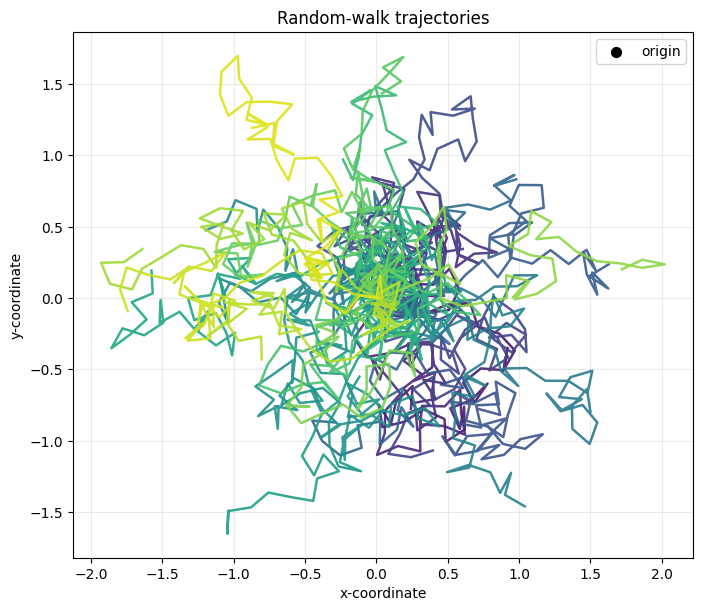

In [5]:
colors = plt.cm.viridis(np.linspace(0.08, 0.95, N_TRIALS))

fig, ax = plt.subplots(figsize=(8, 8))
for k, color in enumerate(colors):
    ax.plot(positions[k, :, 0], positions[k, :, 1], color=color, lw=1.8, alpha=0.9)
    ax.scatter(positions[k, 0, 0], positions[k, 0, 1], color=color, s=14)

ax.scatter(0, 0, color="black", s=50, label="origin")
ax.set_title("Random-walk trajectories")
ax.set_xlabel("x-coordinate")
ax.set_ylabel("y-coordinate")
ax.set_aspect("equal")
ax.grid(alpha=0.25)
ax.legend()
plt.show()


## 2. Scatter plot of distance from the origin

For each trajectory and each step, we plot the distance

$$\|X_{k,j}\|$$

against the step number $j$.


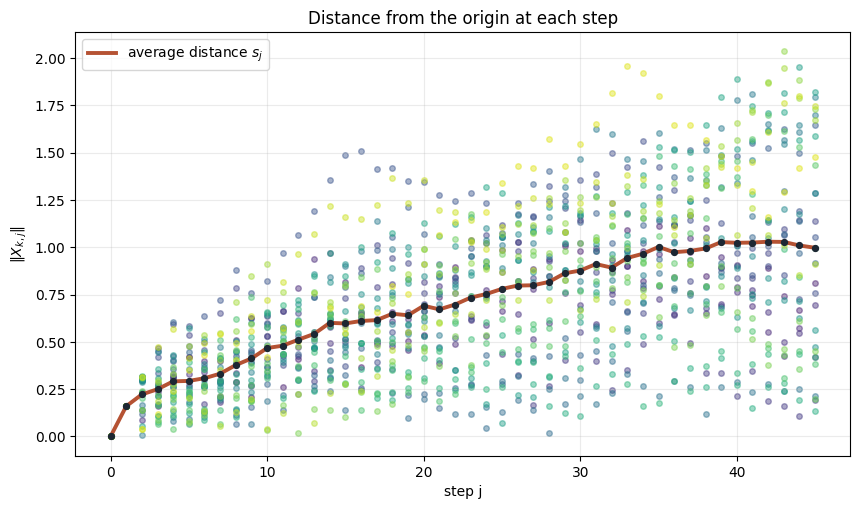

In [6]:
fig, ax = plt.subplots(figsize=(10, 5.5))
for k, color in enumerate(colors):
    ax.scatter(steps, distances[k], color=color, s=16, alpha=0.45)

ax.plot(steps, s, color="#b55233", lw=2.8, label=r"average distance $s_j$")
ax.scatter(steps, s, color="#1d2733", s=18, zorder=3)

ax.set_title("Distance from the origin at each step")
ax.set_xlabel("step j")
ax.set_ylabel(r"$\|X_{k,j}\|$")
ax.grid(alpha=0.25)
ax.legend()
plt.show()


## 3. Plot the mean distance

Let

$$s_j = \frac{1}{K}\sum_{k=1}^K \|X_{k,j}\|,$$

where $K$ is the number of trials. The next plot shows $s_j$ as a function of step.


In [9]:
x = np.sqrt(steps)
a, b = np.polyfit(x, s, 1)
s_fit = a * x + b

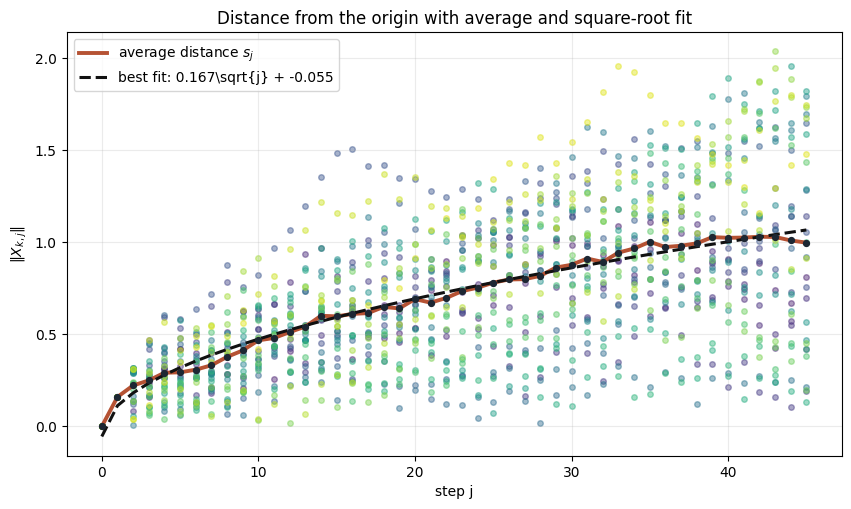

In [10]:
fig, ax = plt.subplots(figsize=(10, 5.5))
for k, color in enumerate(colors):
    ax.scatter(steps, distances[k], color=color, s=16, alpha=0.45)

ax.plot(steps, s, color="#b55233", lw=2.8, label=r"average distance $s_j$")
ax.scatter(steps, s, color="#1d2733", s=18, zorder=3)
ax.plot(steps, s_fit, color="#111111", lw=2.2, ls="--",
        label=fr"best fit: {a:.3f}\sqrt{{j}} + {b:.3f}")

ax.set_title("Distance from the origin with average and square-root fit")
ax.set_xlabel("step j")
ax.set_ylabel(r"$\|X_{k,j}\|$")
ax.grid(alpha=0.25)
ax.legend()
plt.show()